## Analyze connected components

In [1]:
library(tidyverse)
components <- read_csv(
    "networks/results/connected_components.csv"
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `` -> `...1`
Rows: 10 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (4): ...1, Threshold, Connected_components, Largest_component

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [2]:
components

...1,Threshold,Connected_components,Largest_component
<dbl>,<dbl>,<dbl>,<dbl>
0,0.1500000,89,25788
1,0.1888889,665,25179
2,0.2277778,2856,22794
3,0.2666667,7507,17347
4,0.3055556,13298,9960
5,0.3444444,18305,2971
6,0.3833333,21486,193
7,0.4222222,23366,49
8,0.4611111,24431,30


## Degree distribution of papers in the networks

In [13]:
library(tidyverse)
degrees <- read_csv(
    "networks/results/degree_distribution.csv"
)

New names:
• `` -> `...1`
Rows: 25877 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Topic
dbl (2): ...1, Degree

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


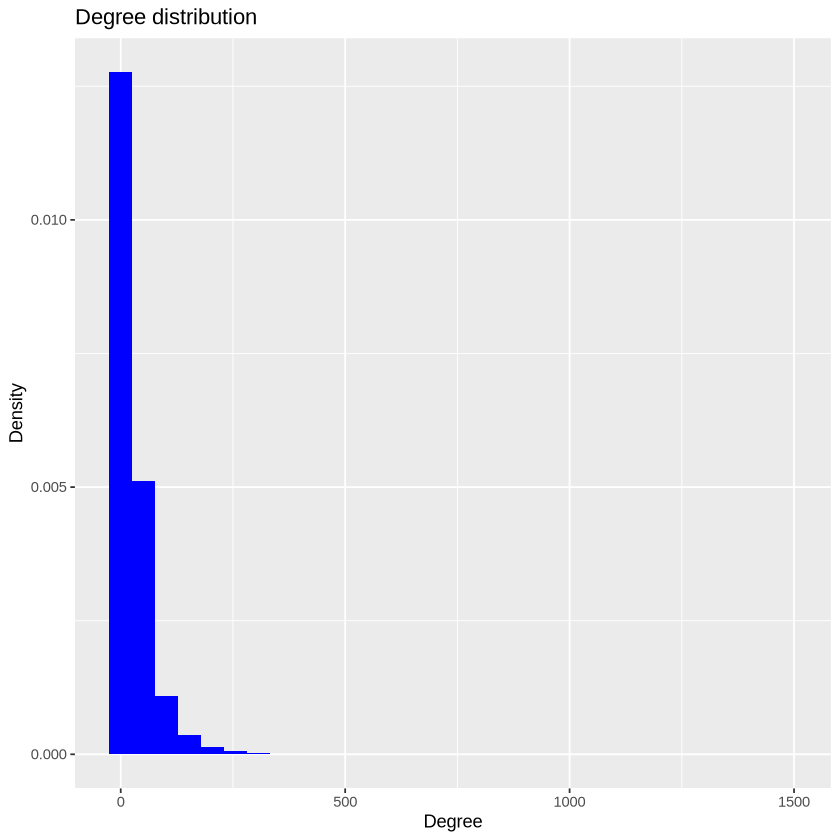

In [25]:
ggplot(data = degrees, aes(x = Degree)) +
    geom_histogram(bins = 30, fill = "blue", aes(y = after_stat(density))) +
    labs(title = "Degree distribution", x = "Degree", y = "Density")

Degree distribution looks like a power law, but of course this needs to be verified. Certainly we don't have a random network.

OLD COMMENT FOR OLD NETWORK

For what we can see, the papers with the highest degree are those with a short abstract, or written in another language (typically Spanish). Since they don't have much words in common with the other papers, their distance tends to 0, so they have a lot of links. Then I need to check two roads:

1) Maybe we made an error: it is better to put a link between papers with distance higher than a certain value, meaning that they have a lot of words in common
2) If the method above does not work, try to remove the papers with the highest degrees, and study the remaining network (hoping that it clusters the topics).

Probably the best solution is to try both ways.

The significative difference between mean and median makes it easy to think that we are not in front of a symmetric distribution, so it is another proof against the random network hypothesis

## Plot degree versus clustering coefficient/eigenvector centrality/knn

In [1]:
library(tidyverse)
centrality_measures <- read_csv(
    "networks/results/abstract_embeddings/centrality_measures.csv"
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `` -> `...1`
Rows: 25877 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Topic
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
colnames(centrality_measures)

[1] "...1"                   "Degree"                 "Clustering_coefficient"
[4] "Eigenvector_centrality" "Mean_degree_NN"         "Topic"

In [ ]:
#centrality_measures <- centrality_measures %>%
    #filter(Degree <= 100)

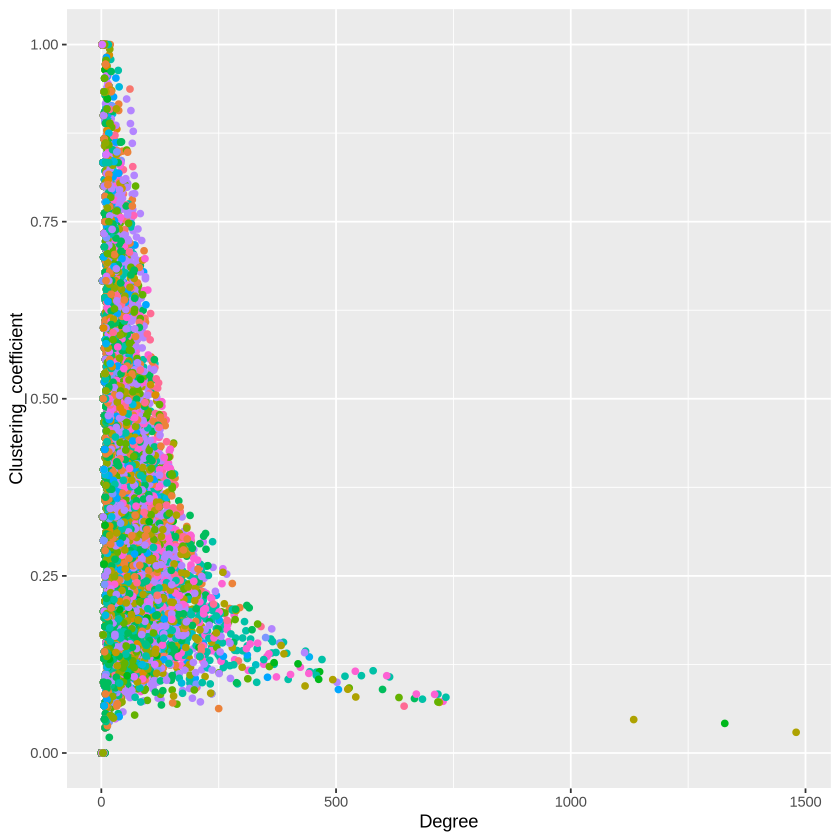

In [4]:
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

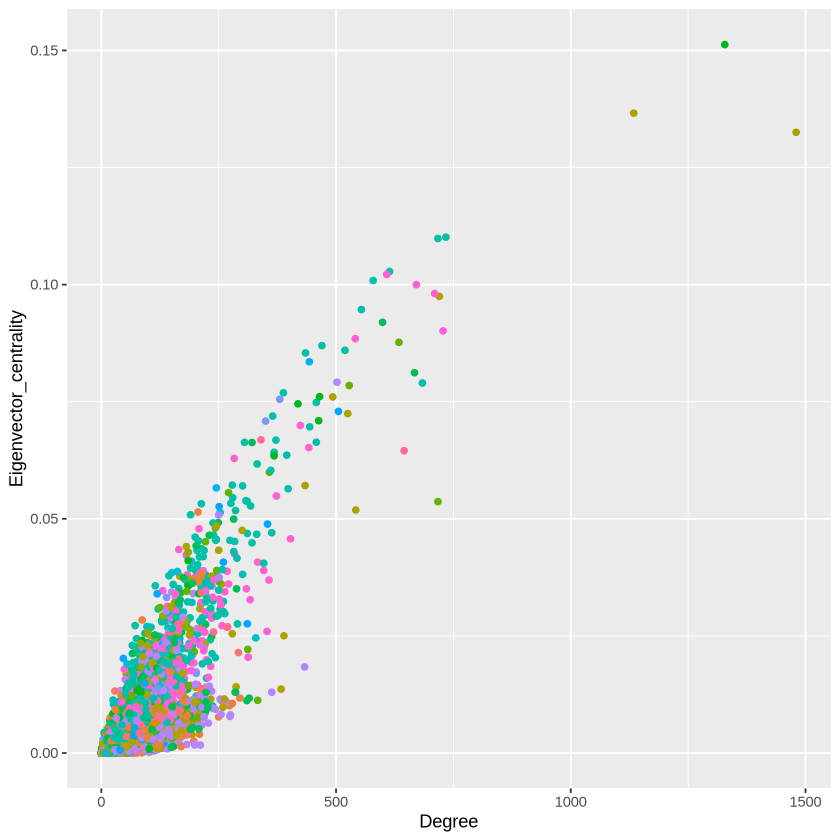

In [5]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

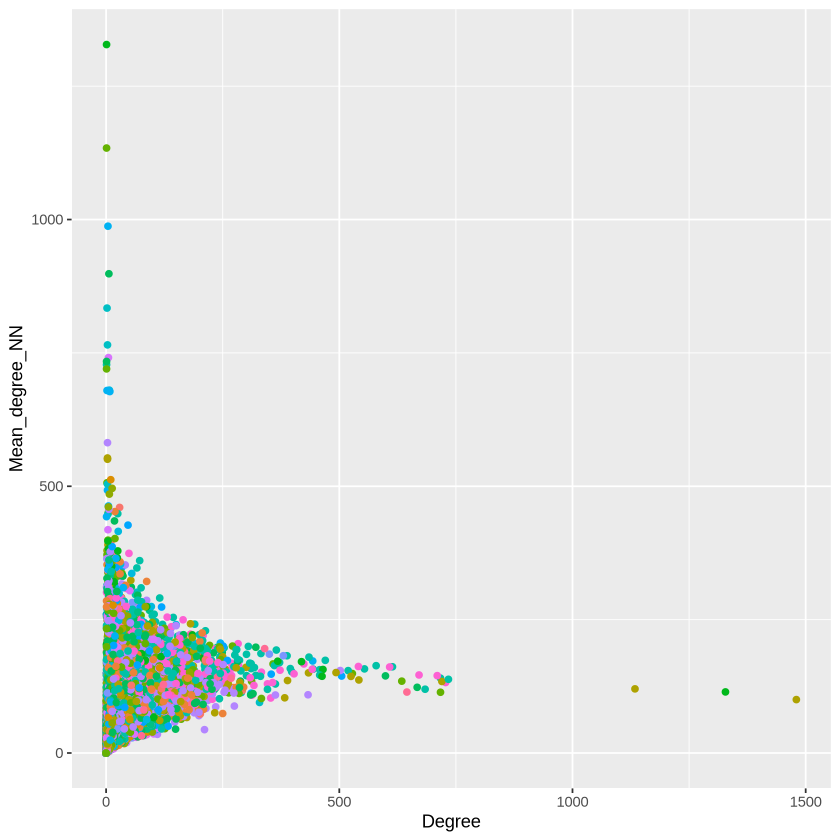

In [ ]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

From this plot we can see that the three nodes with higher degrees are connected to lower degree nodes (otherwise the mean degree of their nearest neighbours would be much higher).

WRONG: the three nodes with higher degree are actually connected between them. It is just that the other nodes connected to them have a lower degree, and so the mean decreases a lot.

## Analyze network degrees

In [2]:
#create a unique dataset with the papers and their degree (and topic)
all_papers <- read_csv(
    "data/all_papers.csv"
)
all_data <- bind_cols(all_papers, centrality_measures)

New names:
• `` -> `...1`
Rows: 25877 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): authors, title, abstract, primary_cathegory, secondary_cathegory
dbl (2): ...1, paper

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `...1` -> `...8`


In [15]:
all_data %>%
    select(c("paper", "title", "primary_cathegory", "secondary_cathegory", "Degree", "Topic")) %>%
    mutate("Index" = c(0:(nrow(all_data) - 1))) %>%
    arrange(desc(Degree)) %>%
    top_n(3, Degree)

paper,title,primary_cathegory,secondary_cathegory,Degree,Topic,Index
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
2512.205,Precision spectroscopy of the 2S-$n$P transitions in atomic hydrogen,Atomic Physics,Atomic Physics,1480,Atomic Physics,17128
2508.166,Classical Dirac particle II. Interaction with an electromagnetic plane wave,Classical Physics,Classical Physics,1328,Classical Physics,10651
2507.147,Nuclear-spin-related properties of~the dual-frequency Doppler-free resonance,Atomic Physics,Atomic Physics,1134,Atomic Physics,9132


These are the three papers with higher degree

In [4]:
## filter nodes with degree 0 and 1
core_data <- all_data %>%
    filter(Degree != 0 & Degree != 1)

In [5]:
nrow(core_data)

[1] 23659

The number of nodes with degree higher than 1 in the original network is close to the number of nodes remained after the removal of pendant nodes. So the network is composed by a strong component where each node has at least two links: paper are highly connected between them. We will see how we can separate them into communities.

At this point it is also useless to compute centrality measures for the network after pendant nodes removal: they will be very similar to those obtained with the original network.

## Comparison with random network

In [6]:
library(tidyverse)
centrality_measures <- read_csv(
    "networks/results/random_network/centrality_measures.csv"
)

New names:
• `` -> `...1`
Rows: 25877 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Topic
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


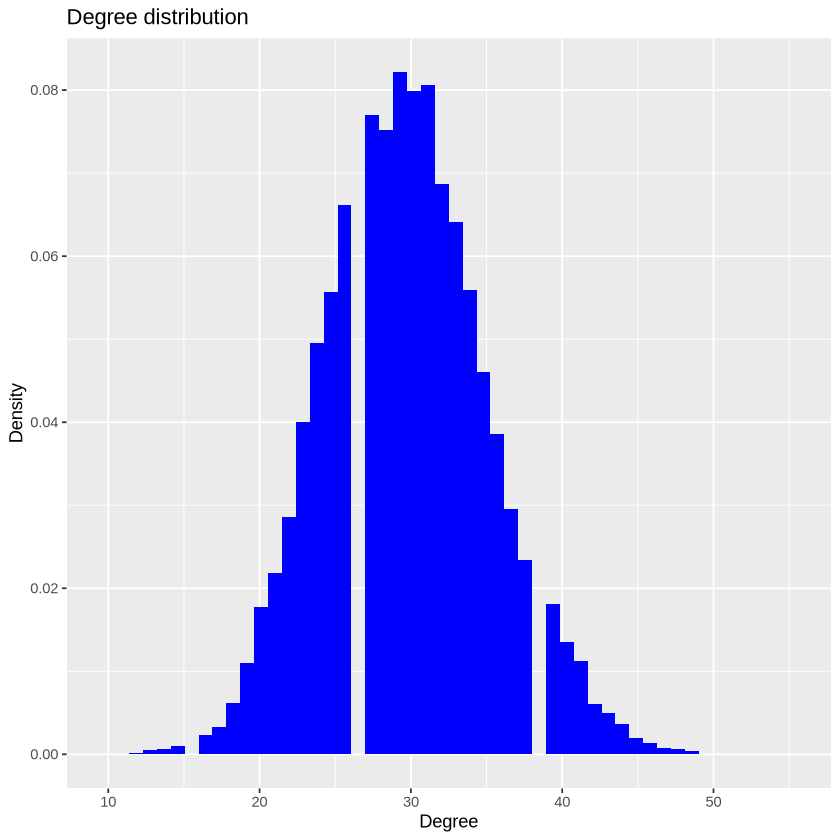

In [7]:
#degree distribution
ggplot(data = centrality_measures, aes(x = Degree)) +
    geom_histogram(bins = 50, fill = "blue", aes(y = after_stat(density))) +
    labs(title = "Degree distribution", x = "Degree", y = "Density")

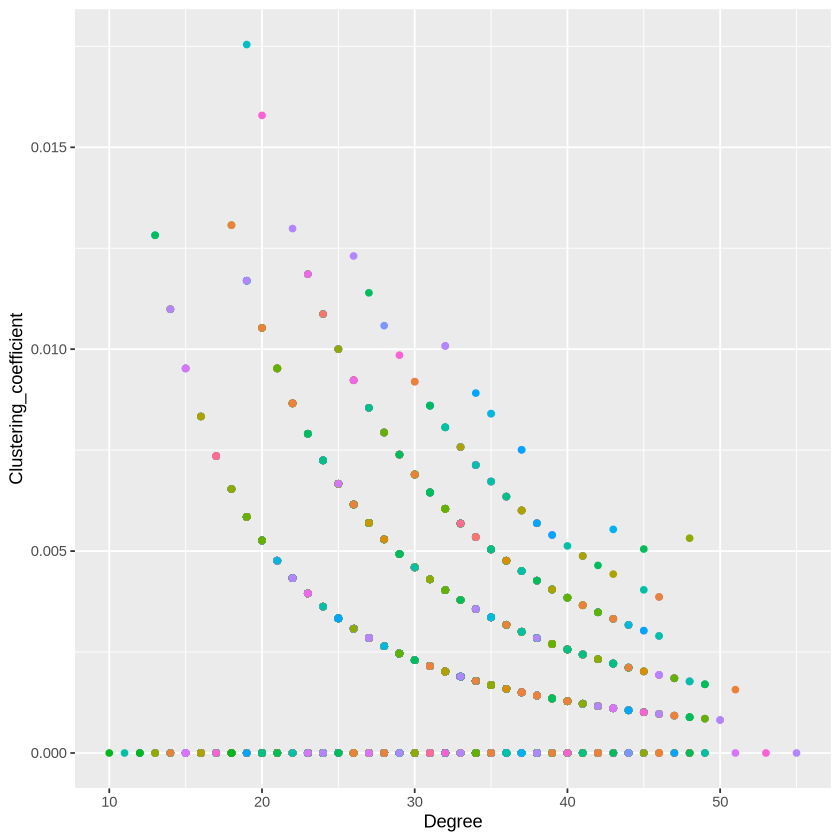

In [8]:
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

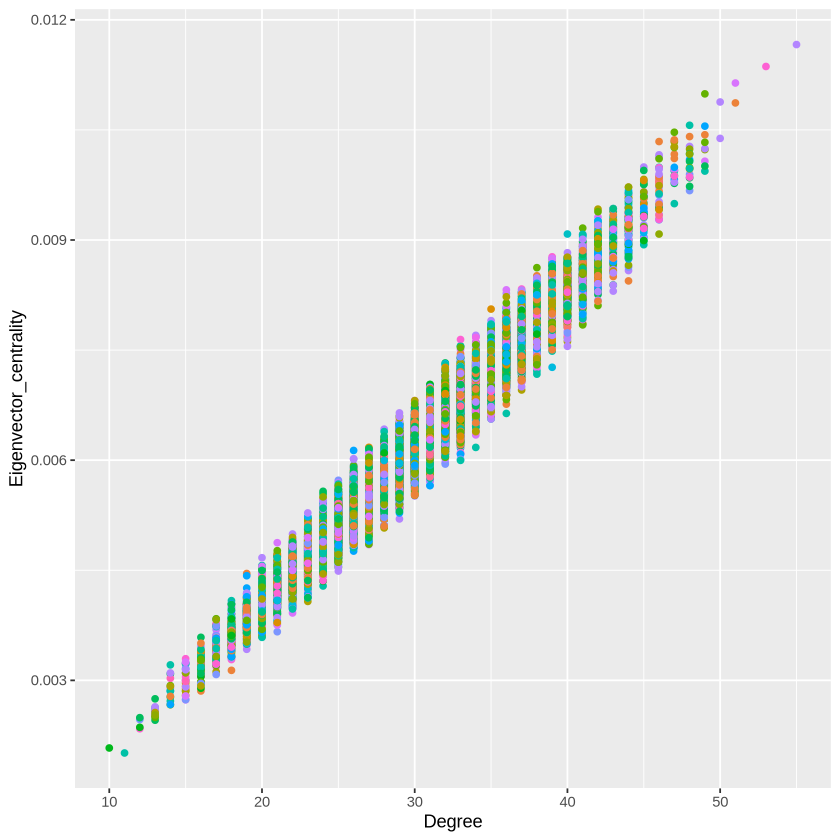

In [9]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

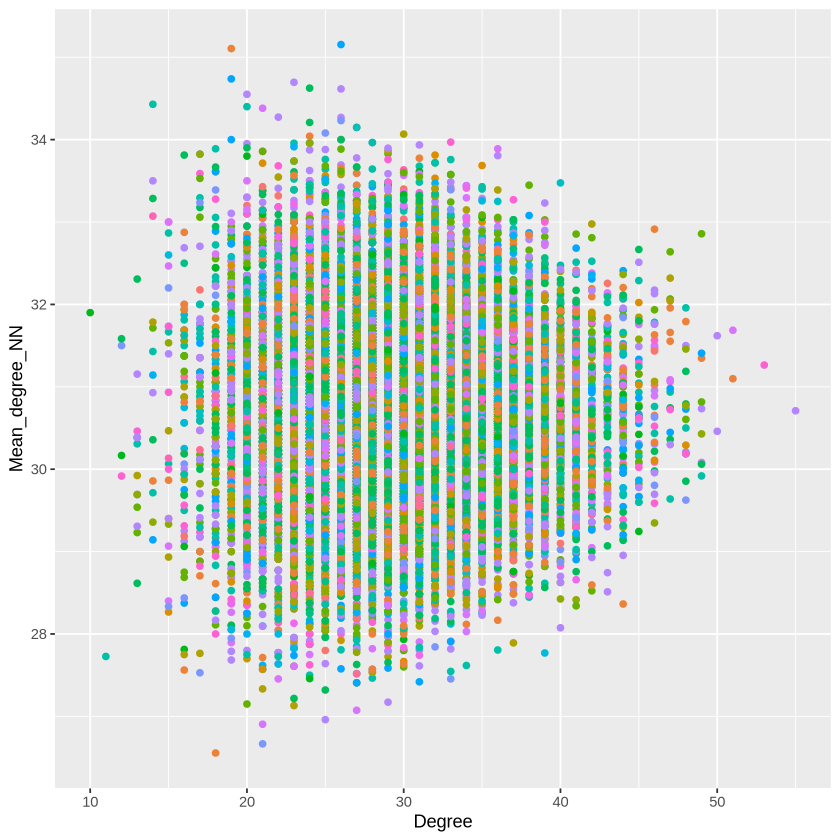

In [10]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN, color = Topic)) +
    geom_point() +
    theme(legend.position = "none")

Completely random relation between k and knn, as expected

## Comparison with scale free